# Read Data

In [1]:
import sys
sys.path.append('../')

pip install pandas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import concurrent.futures
from tqdm import tqdm


/home/fsoto/miniconda3/envs/SSL/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
lcs = pd.read_parquet('../data/fpv2/lcs')
#remove nan values
lcs = lcs.dropna()

In [4]:
lcs.head()

,oid,index,mjd,fid,mag_tot,sigma_mag_tot,flux_diff_ujy,sigma_flux_diff_ujy,detected
0,ZTF17aaaazva,4,58208.473333,1,19.181563,0.318209,-18.430364,22.613968,False
1,ZTF17aaaazva,7,58209.503738,1,19.032334,0.136859,-7.062148,11.159140,False
2,ZTF17aaaazva,9,58210.514653,1,18.783237,0.077154,15.766591,7.913231,False
3,ZTF17aaaazva,12,58218.490984,2,17.048151,0.007773,16.404996,3.941138,False
4,ZTF17aaaazva,14,58218.517361,2,17.178976,0.019256,-46.084027,8.655147,True


In [5]:
partitions = pd.read_parquet('../data/fpv2/partitions.parquet')

In [6]:
classes = partitions['alerceclass'].unique()
classes

array(['AGN', 'QSO', 'EA', 'YSO', 'SNIa', 'CV/Nova', 'RRLc', 'RSCVn',
       'Blazar', 'SNII', 'EB/EW', 'LPV', 'CEP', 'RRLab', 'Periodic-Other',
       'DSCT', 'SNIbc', 'SLSN', 'TDE', 'SNIIb', 'SNIIn', 'Microlensing'],
      dtype=object)

In [7]:
periodic_classes = ['EA','RRLc', 'RSCVn', 'EB/EW', 'LPV', 'CEP', 'RRLab', 'Periodic-Other','DSCT']

In [8]:
partitions_periodic = partitions[partitions['alerceclass'].isin(periodic_classes)]
partitions_periodic.head()

,oid,alerceclass,partition
index,,,
17103,ZTF18aayfbqd,EA,test
32172,ZTF17aaajmxw,RRLc,test
41621,ZTF22aaahdyl,RSCVn,test
11262,ZTF19abnqhwd,EA,test
17272,ZTF17aacihzd,RSCVn,test


In [9]:
unique_oids_periodic = partitions_periodic['oid'].unique()
len(unique_oids_periodic)

23567

In [10]:
periods = pd.read_parquet('../data/fpv2/periods.parquet')
periods.shape

(23559, 5)

In [11]:
periods

,name,value,fid,version,oid
0,Multiband_period,0.495773,12.0,lc_classifier_1.2.1-P,ZTF18aayfbqd
1,Multiband_period,0.361698,12.0,lc_classifier_1.2.1-P,ZTF17aaajmxw
2,Multiband_period,1.170744,12.0,lc_classifier_1.2.1-P,ZTF17aacihzd
3,Multiband_period,0.195022,12.0,lc_classifier_1.2.1-P,ZTF17aaaoite
4,Multiband_period,333.333330,12.0,lc_classifier_1.2.1-P,ZTF18abcurfb
...,...,...,...,...,...
23554,Multiband_period,0.702447,12.0,manual,ZTF21aagfttq
23555,Multiband_period,0.240663,12.0,manual,ZTF19abejoeg
23556,Multiband_period,0.999349,12.0,manual,ZTF19acifcsb
23557,Multiband_period,0.270542,12.0,manual,ZTF19aaipypp


In [12]:
periodic_classes_reduced = ['EA','EB/EW','RRLc', 'CEP', 'RRLab']

In [13]:
partitions_periodic_reduced = partitions[partitions['alerceclass'].isin(periodic_classes_reduced)]

In [14]:
partitions_periodic_reduced_unique = partitions_periodic_reduced.drop_duplicates(subset='oid')

In [15]:
partitions_periodic_reduced_oids = partitions_periodic_reduced['oid'].unique()

In [16]:
periods_periodic_reduced = periods[periods['oid'].isin(partitions_periodic_reduced_oids)]
len(periods_periodic_reduced)

14990

In [17]:
periods_periodic_reduced_with_class = pd.merge(periods_periodic_reduced, partitions_periodic_reduced_unique[['oid','alerceclass']], on='oid', how='left')

In [18]:
#plot histogram of periods for each class
periods_periodic_reduced_with_class.head()

,name,value,fid,version,oid,alerceclass
0,Multiband_period,0.495773,12.0,lc_classifier_1.2.1-P,ZTF18aayfbqd,EA
1,Multiband_period,0.361698,12.0,lc_classifier_1.2.1-P,ZTF17aaajmxw,RRLc
2,Multiband_period,0.195022,12.0,lc_classifier_1.2.1-P,ZTF17aaaoite,EB/EW
3,Multiband_period,3.270787,12.0,lc_classifier_1.2.1-P,ZTF18adbbyzu,CEP
4,Multiband_period,0.602792,12.0,lc_classifier_1.2.1-P,ZTF18abukrnx,RRLab


In [19]:
#plot histogram of log10(period) for each class 
periods_periodic_reduced_with_class['log10_period'] = np.log10(periods_periodic_reduced_with_class['value'])

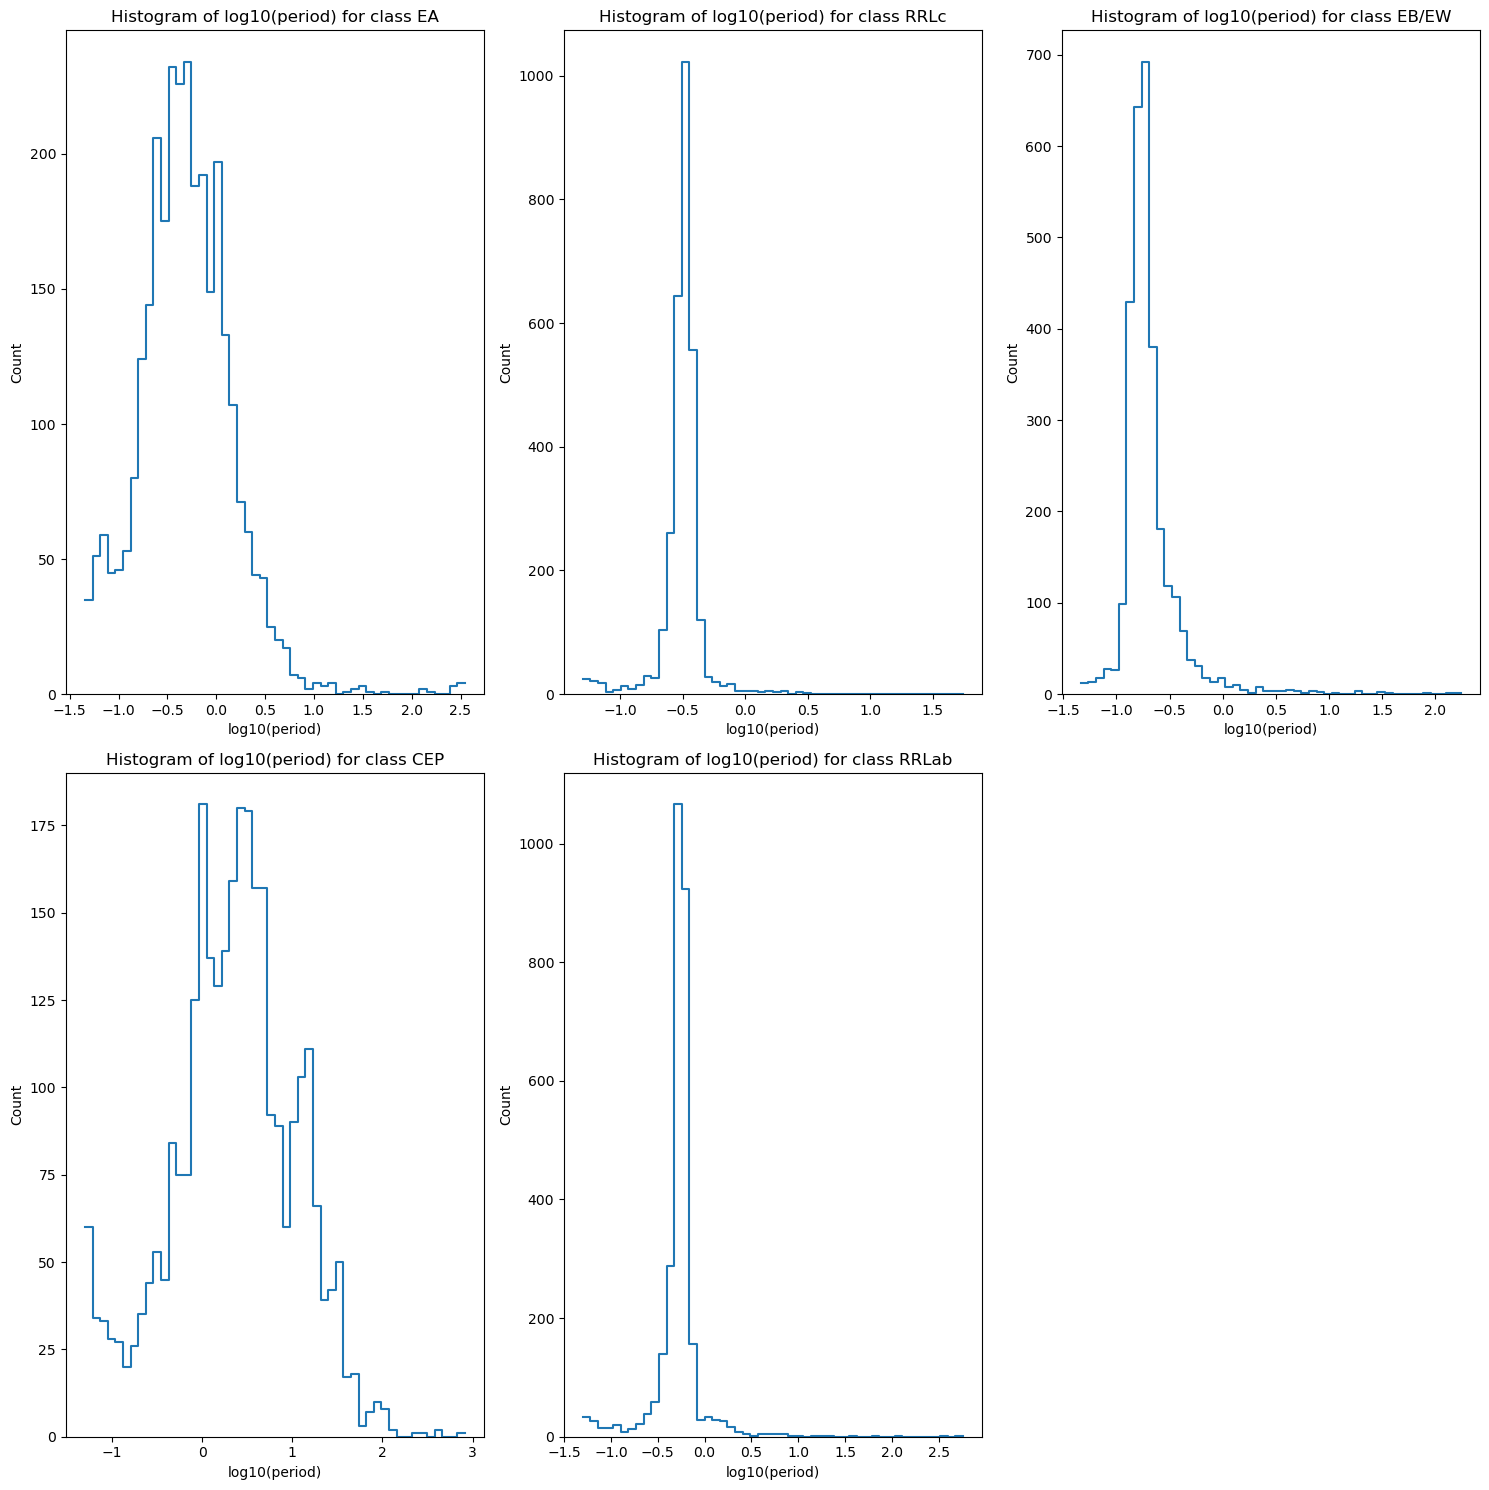

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming periods_periodic_reduced_with_class is a DataFrame with columns 'log10_period' and 'alerceclass'

# Get unique classes
unique_classes = periods_periodic_reduced_with_class['alerceclass'].unique()

# Create subplots in a 3x2 grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through each class and create a histogram
for ax, cls in zip(axes, unique_classes):
    sns.histplot(data=periods_periodic_reduced_with_class[periods_periodic_reduced_with_class['alerceclass'] == cls], 
                 x='log10_period', bins=50, ax=ax, fill=False, element='step')
    ax.set_xlabel('log10(period)')
    ax.set_ylabel('Count')
    ax.set_title(f'Histogram of log10(period) for class {cls}')

# Hide any unused subplots
for i in range(len(unique_classes), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [21]:
def process_bins(lc, n_bins, sensibilidad,row_name='mjd'):
    if len(lc) > 50 and n_bins > 5:
        bins = pd.cut(lc[row_name], bins=n_bins, duplicates='drop')
        bin_counts = bins.value_counts().sort_values(ascending=False)
        mean_bin_counts = bin_counts.mean()
        std_bin_counts = bin_counts.std()

        # Identify bins exceeding threshold
        removed_bin_index = bin_counts[bin_counts > mean_bin_counts + sensibilidad * std_bin_counts].index

        # Select and remove rows from the original DataFrame
        removed_bin_lc = lc[bins.isin(removed_bin_index)]
        lc = lc[~bins.isin(removed_bin_index)]

        # Check if removed_bin_lc is empty before trying to bin it
        if not removed_bin_lc.empty:
            # Recompute bins for the removed rows to avoid reindexing issues
            removed_bin_lc_bins = pd.cut(removed_bin_lc[row_name], bins=n_bins, duplicates='drop')

            # Randomly sample values from removed bins
            random_samples = []
            for bin in removed_bin_index:
                bin_data = removed_bin_lc[removed_bin_lc_bins == bin]
                sample_size = int(mean_bin_counts)
                if len(bin_data) >= sample_size:
                    sampled_data = bin_data.sample(n=sample_size, random_state=42)
                else:
                    sampled_data = bin_data
                random_samples.append(sampled_data)

            # Concatenate sampled rows
            if random_samples:  # Ensure there's data to concatenate
                random_sampled_rows = pd.concat(random_samples)
                lc = pd.concat([lc, random_sampled_rows])

    return lc

In [29]:

import matplotlib.pyplot as plt

def plot_lightcurve(oid,n,del_bin=False,bins_percent=1,sensibilidad=10,max_len=1000):
    # Ensure the period and class are correctly extracted
    period = periods_periodic_reduced.loc[periods_periodic_reduced['oid'] == oid, 'value'].values[0]
    obj_class = periods_periodic_reduced_with_class.loc[periods_periodic_reduced_with_class['oid'] == oid, 'alerceclass'].values[0]
    
    # Filter the light curves for the given object ID
    lc = lcs[lcs['oid'] == oid]
    red_lc = lc[lc['fid'] == 2].copy()
    green_lc = lc[lc['fid'] == 1].copy()
    # Limit the number of points to plot
    red_lc_og = red_lc.copy()
    green_lc_og = green_lc.copy()
    # get max bin for each band of mag_tot and eliminate the max bin
    print('Red Length:',len(red_lc))
    print('Green Length:',len(green_lc))
    n_bins_red = int(len(red_lc)*bins_percent)
    n_bins_green = int(len(green_lc)*bins_percent)
    if del_bin:
        red_lc = process_bins(red_lc, n_bins_red, sensibilidad, row_name='mjd')
        green_lc = process_bins(green_lc, n_bins_green, sensibilidad, row_name='mjd')

        red_lc = process_bins(red_lc, n_bins_red, sensibilidad, row_name='mag_tot')
        green_lc = process_bins(green_lc, n_bins_green, sensibilidad, row_name='mag_tot')

        print('New Red Length:',len(red_lc))
        print('New Green Length:',len(green_lc))
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
    red_lc = red_lc.head(max_len)
    green_lc = green_lc.head(max_len)
    # Plot the original light curve
    axes[0,0].plot(red_lc_og['mjd'], red_lc_og['mag_tot'], 'ro', label='Red band')
    axes[0,0].plot(green_lc_og['mjd'], green_lc_og['mag_tot'], 'go', label='Green band')
    axes[0,0].invert_yaxis()
    axes[0,0].set_xlabel('MJD')
    axes[0,0].set_ylabel('Magnitude')
    axes[0,0].set_title(f'Light curve for object {oid} (Class: {obj_class})')
    axes[0,0].legend()

    # Plot the folded light curve
    
    red_lc_og['phase'] = (red_lc_og['mjd'] % (n*period)) / period
    green_lc_og['phase'] = (green_lc_og['mjd'] % (n*period)) / period
    axes[1,0].plot(red_lc_og['phase'], red_lc_og['mag_tot'], 'ro', label='Red band')
    axes[1,0].plot(green_lc_og['phase'], green_lc_og['mag_tot'], 'go', label='Green band')
    axes[1,0].invert_yaxis()
    axes[1,0].set_xlabel('Phase')
    axes[1,0].set_ylabel('Magnitude')
    axes[1,0].set_title(f'Folded light curve for object {oid} (Class: {obj_class}) with period {period}')
    axes[1,0].legend()


    axes[0,1].plot(red_lc['mjd'], red_lc['mag_tot'], 'ro', label='Red band')
    axes[0,1].plot(green_lc['mjd'], green_lc['mag_tot'], 'go', label='Green band')
    axes[0,1].invert_yaxis()
    axes[0,1].set_xlabel('MJD')
    axes[0,1].set_ylabel('Magnitude')
    axes[0,1].set_title(f'Light curve for object {oid} (Class: {obj_class})')
    axes[0,1].legend()

    # Plot the folded light curve
    red_lc['phase'] = (red_lc['mjd'] % (n*period)) / period
    green_lc['phase'] = (green_lc['mjd'] % (n*period)) / period
    axes[1,1].plot(red_lc['phase'], red_lc['mag_tot'], 'ro', label='Red band')
    axes[1,1].plot(green_lc['phase'], green_lc['mag_tot'], 'go', label='Green band')
    axes[1,1].invert_yaxis()
    axes[1,1].set_xlabel('Phase')
    axes[1,1].set_ylabel('Magnitude')
    axes[1,1].set_title(f'Folded light curve for object {oid} (Class: {obj_class}) with period {period}')
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

Red Length: 1049
Green Length: 561


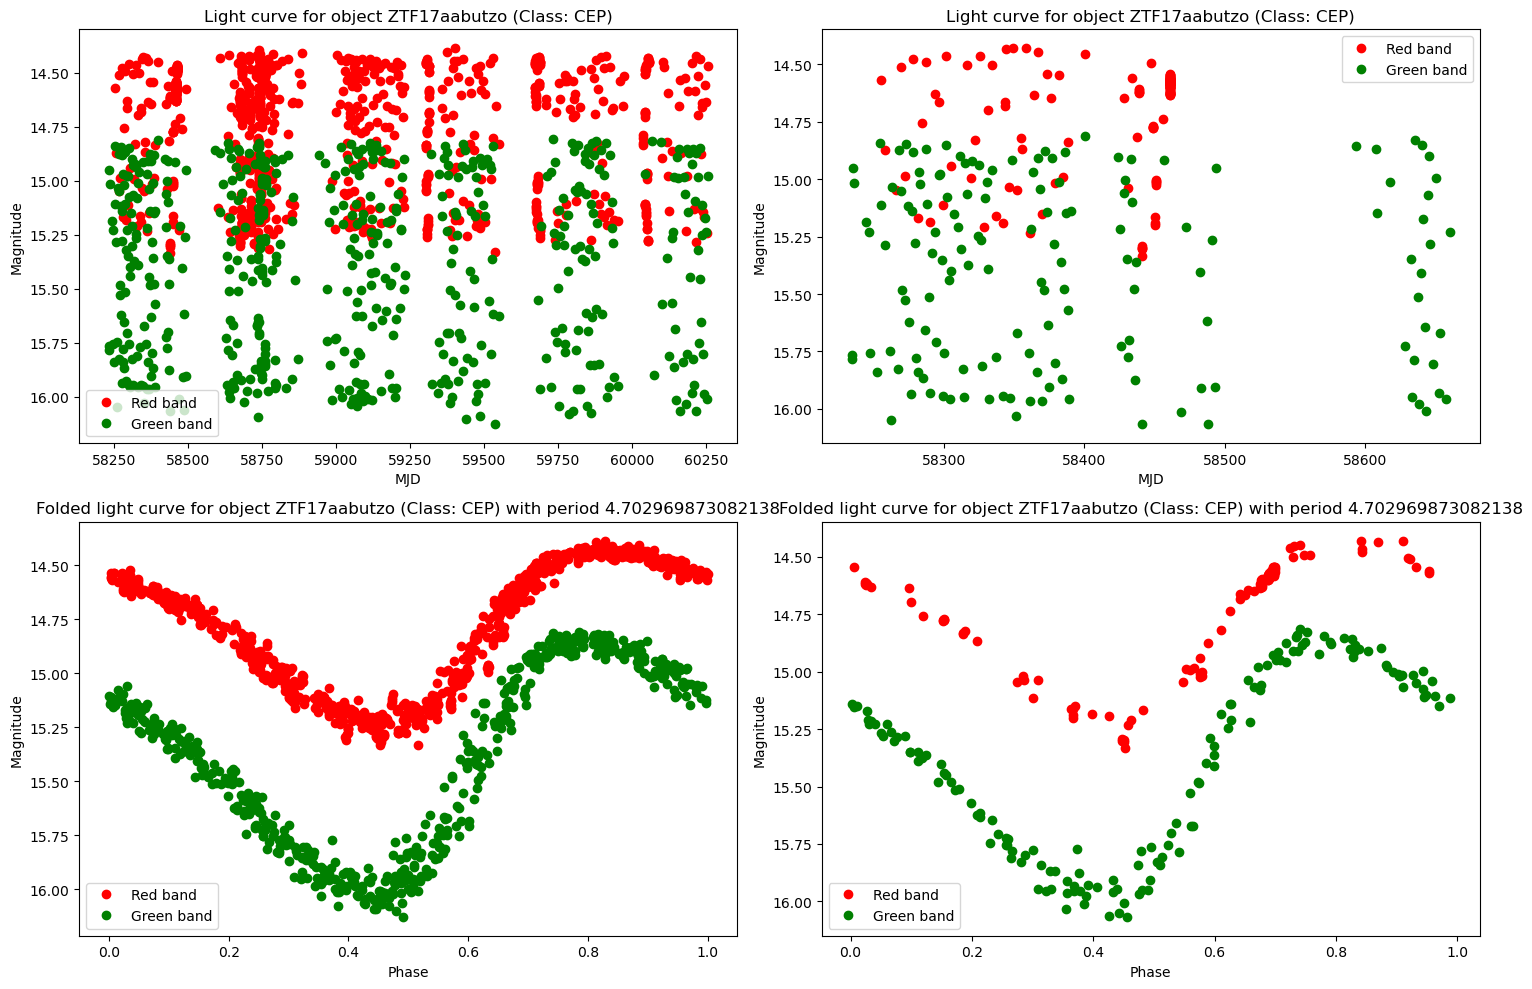

In [46]:
id = 'ZTF17aabutzo'
plot_lightcurve(id, 1, del_bin=False, bins_percent=0.05,sensibilidad=3,max_len=150)
